# 🧠 Alzheimer MRI Classification with VGG16 (Google Colab)
Full pipeline: Download dataset from Kaggle → Preprocess → Train VGG16 model → Fine-tune → Visualize results

In [ ]:
from google.colab import files


# Upload kaggle.json
uploaded = files.upload()

# Move to proper directory and set permissions
!mkdir -p /root/.kaggle
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("✅ kaggle.json configured.")

# Download and unzip dataset
!kaggle datasets download -d uraninjo/augmented-alzheimer-mri-dataset -q
!unzip -q augmented-alzheimer-mri-dataset.zip -d /content/alzheimer_dataset
!ls /content/alzheimer_dataset


Saving kaggle.json to kaggle.json
✅ kaggle.json configured.
Dataset URL: https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset
License(s): GNU Lesser General Public License 3.0
AugmentedAlzheimerDataset  OriginalDataset


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = '/content/alzheimer_dataset/AugmentedAlzheimerDataset'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_indices = train_generator.class_indices
print("✅ Class indices:", class_indices)


Found 27188 images belonging to 4 classes.
Found 6796 images belonging to 4 classes.
✅ Class indices: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


In [ ]:
class_indices

{'MildDemented': 0,
 'ModerateDemented': 1,
 'NonDemented': 2,
 'VeryMildDemented': 3}

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load VGG16 base
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Build the model
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ModelCheckpoint('best_alzheimer_model.h5', save_best_only=True, monitor='val_accuracy')
]

# Train (phase 1)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.5505 - loss: 1.0115

850/850 ━━━━━━━━━━━━━━━━━━━━ 207s 226ms/step - accuracy: 0.6284 - loss: 0.8454 - val_accuracy: 0.7135 - val_loss: 0.6454
Epoch 2/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.7225 - loss: 0.6485

850/850 ━━━━━━━━━━━━━━━━━━━━ 181s 213ms/step - accuracy: 0.7334 - loss: 0.6236 - val_accuracy: 0.7980 - val_loss: 0.5216
Epoch 3/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.7734 - loss: 0.5462

850/850 ━━━━━━━━━━━━━━━━━━━━ 181s 213ms/step - accuracy: 0.7806 - loss: 0.5290 - val_accuracy: 0.8328 - val_loss: 0.4374
Epoch 4/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8083 - loss: 0.4725

850/850 ━━━━━━━━━━━━━━━━━━━━ 181s 213ms/step - accuracy: 0.8171 - loss: 0.4550 - val_accuracy: 0.8540 - val_loss: 0.3881
Epoch 5/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8392 - loss: 0.4089

...

850/850 ━━━━━━━━━━━━━━━━━━━━ 181s 213ms/step - accuracy: 0.8735 - loss: 0.3254 - val_accuracy: 0.8976 - val_loss: 0.2721
Epoch 8/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 181s 213ms/step - accuracy: 0.8938 - loss: 0.2844 - val_accuracy: 0.8867 - val_loss: 0.2869
Epoch 9/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9027 - loss: 0.2620

850/850 ━━━━━━━━━━━━━━━━━━━━ 181s 213ms/step - accuracy: 0.9057 - loss: 0.2542 - val_accuracy: 0.9233 - val_loss: 0.2177
Epoch 10/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 180s 212ms/step - accuracy: 0.9093 - loss: 0.2417 - val_accuracy: 0.9085 - val_loss: 0.2311
Epoch 11/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 181s 213ms/step - accuracy: 0.9198 - loss: 0.2177 - val_accuracy: 0.9227 - val_loss: 0.2012
Epoch 12/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9262 - loss: 0.2014

850/850 ━━━━━━━━━━━━━━━━━━━━ 181s 213ms/step - accuracy: 0.9271 - loss: 0.2004 - val_accuracy: 0.9329 - val_loss: 0.1805
Epoch 13/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 181s 213ms/step - accuracy: 0.9288 - loss: 0.1949 - val_accuracy: 0.9236 - val_loss: 0.1924
Epoch 14/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9358 - loss: 0.1795

850/850 ━━━━━━━━━━━━━━━━━━━━ 181s 213ms/step - accuracy: 0.9380 - loss: 0.1750 - val_accuracy: 0.9448 - val_loss: 0.1626
Epoch 15/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9400 - loss: 0.1707

850/850 ━━━━━━━━━━━━━━━━━━━━ 186s 219ms/step - accuracy: 0.9380 - loss: 0.1721 - val_accuracy: 0.9450 - val_loss: 0.1563


In [ ]:
# Unfreeze top 4 layers of VGG16
for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune (phase 2)
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9486 - loss: 0.1437

850/850 ━━━━━━━━━━━━━━━━━━━━ 217s 247ms/step - accuracy: 0.9486 - loss: 0.1437 - val_accuracy: 0.9613 - val_loss: 0.1105
Epoch 2/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9742 - loss: 0.0776

850/850 ━━━━━━━━━━━━━━━━━━━━ 206s 242ms/step - accuracy: 0.9742 - loss: 0.0776 - val_accuracy: 0.9698 - val_loss: 0.0858
Epoch 3/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9837 - loss: 0.0519

850/850 ━━━━━━━━━━━━━━━━━━━━ 260s 239ms/step - accuracy: 0.9837 - loss: 0.0519 - val_accuracy: 0.9751 - val_loss: 0.0653
Epoch 4/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9858 - loss: 0.0439

850/850 ━━━━━━━━━━━━━━━━━━━━ 204s 241ms/step - accuracy: 0.9858 - loss: 0.0439 - val_accuracy: 0.9768 - val_loss: 0.0662
Epoch 5/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9914 - loss: 0.0310

850/850 ━━━━━━━━━━━━━━━━━━━━ 204s 240ms/step - accuracy: 0.9914 - loss: 0.0310 - val_accuracy: 0.9784 - val_loss: 0.0667
Epoch 6/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9942 - loss: 0.0218

850/850 ━━━━━━━━━━━━━━━━━━━━ 204s 240ms/step - accuracy: 0.9942 - loss: 0.0218 - val_accuracy: 0.9838 - val_loss: 0.0432
Epoch 7/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 204s 240ms/step - accuracy: 0.9943 - loss: 0.0206 - val_accuracy: 0.9832 - val_loss: 0.0458
Epoch 8/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9945 - loss: 0.0206

850/850 ━━━━━━━━━━━━━━━━━━━━ 204s 240ms/step - accuracy: 0.9945 - loss: 0.0206 - val_accuracy: 0.9843 - val_loss: 0.0529
Epoch 9/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9957 - loss: 0.0148

850/850 ━━━━━━━━━━━━━━━━━━━━ 205s 241ms/step - accuracy: 0.9957 - loss: 0.0148 - val_accuracy: 0.9878 - val_loss: 0.0352
Epoch 10/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 205s 241ms/step - accuracy: 0.9970 - loss: 0.0125 - val_accuracy: 0.9806 - val_loss: 0.0581
Epoch 11/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 205s 241ms/step - accuracy: 0.9964 - loss: 0.0151 - val_accuracy: 0.9860 - val_loss: 0.0401
Epoch 12/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9962 - loss: 0.0132

850/850 ━━━━━━━━━━━━━━━━━━━━ 203s 239ms/step - accuracy: 0.9962 - loss: 0.0132 - val_accuracy: 0.9890 - val_loss: 0.0290
Epoch 13/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 204s 240ms/step - accuracy: 0.9972 - loss: 0.0097 - val_accuracy: 0.9872 - val_loss: 0.0345
Epoch 14/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 203s 239ms/step - accuracy: 0.9973 - loss: 0.0102 - val_accuracy: 0.9848 - val_loss: 0.0422
Epoch 15/15
850/850 ━━━━━━━━━━━━━━━━━━━━ 203s 239ms/step - accuracy: 0.9956 - loss: 0.0155 - val_accuracy: 0.9826 - val_loss: 0.0522


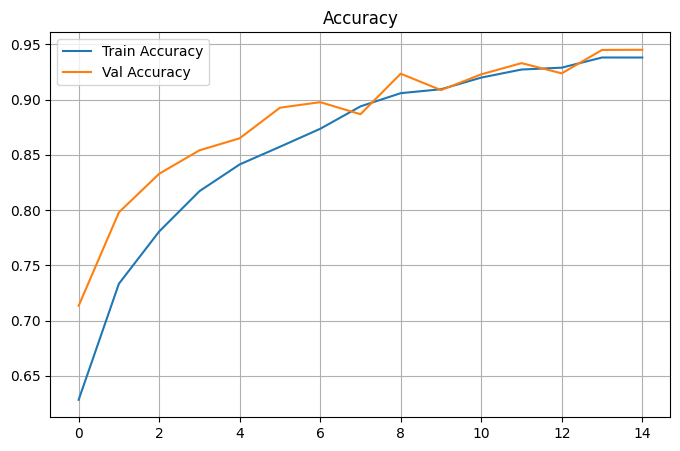

In [ ]:
plt.figure(figsize=(8,5))

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

if 'history_finetune' in globals():
    train_acc += history_finetune.history['accuracy']
    val_acc += history_finetune.history['val_accuracy']

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')

plt.legend(); plt.grid(); plt.title('Accuracy'); plt.show()

In [ ]:
model.save("alzheimer_vgg16_model.h5")
print("✅ Model saved as alzheimer_vgg16_model.h5")


✅ Model saved as alzheimer_vgg16_model.h5


In [ ]:
from google.colab import drive
drive.mount('/content/drive')